# Data Upload and Preprocessing

## Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

## Connecting to Colab

The data files are in Google Drive, and I mounted drive below in order to use the files with Colab.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Uploading the Data

In [3]:
DATA_PATH = "/content/drive/MyDrive/wildfire-prediction-data/data/"
files = os.listdir(DATA_PATH)
print(f"Found {len(files)} files:")
for f in files:
    print(f)

Found 19 files:
next_day_wildfire_spread_eval_00.tfrecord
next_day_wildfire_spread_test_00.tfrecord
next_day_wildfire_spread_eval_01.tfrecord
next_day_wildfire_spread_test_01.tfrecord
next_day_wildfire_spread_train_00.tfrecord
next_day_wildfire_spread_train_01.tfrecord
next_day_wildfire_spread_train_02.tfrecord
next_day_wildfire_spread_train_04.tfrecord
next_day_wildfire_spread_train_03.tfrecord
next_day_wildfire_spread_train_05.tfrecord
next_day_wildfire_spread_train_06.tfrecord
next_day_wildfire_spread_train_07.tfrecord
next_day_wildfire_spread_train_08.tfrecord
next_day_wildfire_spread_train_09.tfrecord
next_day_wildfire_spread_train_10.tfrecord
next_day_wildfire_spread_train_11.tfrecord
next_day_wildfire_spread_train_12.tfrecord
next_day_wildfire_spread_train_13.tfrecord
next_day_wildfire_spread_train_14.tfrecord


Checking the features:

In [4]:
sample_file = DATA_PATH + files[0]
raw_dataset = tf.data.TFRecordDataset(sample_file)
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    print(list(example.features.feature.keys())) # feature names

['tmmn', 'NDVI', 'FireMask', 'population', 'elevation', 'vs', 'pdsi', 'pr', 'tmmx', 'sph', 'th', 'PrevFireMask', 'erc']


## Inspecting the Data

In [5]:
# Define all features
FEATURES = ['tmmn', 'tmmx', 'th', 'vs', 'pr', 'sph', 'pdsi', 'NDVI', 'erc', 'population', 'elevation', 'PrevFireMask', 'FireMask']

feature_description = {f: tf.io.FixedLenFeature([64*64], tf.float32) for f in FEATURES}

def parse_record(raw_record):
    parsed = tf.io.parse_single_example(raw_record, feature_description)
    # Reshape each feature to 64x64
    return {k: tf.reshape(v, [64, 64]) for k, v in parsed.items()}

# Load all 19 files
all_files = [DATA_PATH + f for f in files]
full_dataset = tf.data.TFRecordDataset(all_files).map(parse_record)

# Verify by looking at one sample
for sample in full_dataset.take(1):
    for key, value in sample.items():
        print(f"{key}: shape={value.shape}, min={tf.reduce_min(value):.2f}, max={tf.reduce_max(value):.2f}")

FireMask: shape=(64, 64), min=-1.00, max=0.00
NDVI: shape=(64, 64), min=-4315.00, max=7902.00
PrevFireMask: shape=(64, 64), min=-1.00, max=1.00
elevation: shape=(64, 64), min=74.00, max=155.00
erc: shape=(64, 64), min=13.51, max=22.51
pdsi: shape=(64, 64), min=2.14, max=3.88
population: shape=(64, 64), min=0.00, max=2167.71
pr: shape=(64, 64), min=2.40, max=7.13
sph: shape=(64, 64), min=0.01, max=0.01
th: shape=(64, 64), min=140.82, max=168.41
tmmn: shape=(64, 64), min=277.53, max=280.71
tmmx: shape=(64, 64), min=291.79, max=295.07
vs: shape=(64, 64), min=3.73, max=4.25


Defining the features:

In [6]:
INPUT_FEATURES = [
    'tmmn', 'tmmx', 'th', 'vs', 'pr',
    'sph', 'pdsi', 'NDVI', 'erc', 'population',
    'elevation', 'PrevFireMask',
]
OUTPUT_FEATURE = 'FireMask'
ALL_FEATURES   = INPUT_FEATURES + [OUTPUT_FEATURE]
GRID_SIZE      = 64

In [7]:
# Describing the features
FEATURE_DESC = {
    feat: tf.io.FixedLenFeature([GRID_SIZE * GRID_SIZE], tf.float32)
    for feat in ALL_FEATURES
}

## Load the Data Splits

The data has already been split into training, validation, and test data.

In [8]:
def load_split(data_dir, prefix):
    file_paths = sorted([
        os.path.join(data_dir, f)
        for f in os.listdir(data_dir)
        if f.endswith('.tfrecord') and prefix in f
    ])
    print(f"[{prefix}] found {len(file_paths)} files: {[os.path.basename(p) for p in file_paths]}")

    records = []
    for path in file_paths:
        for raw in tf.data.TFRecordDataset(path):
            parsed = tf.io.parse_single_example(raw, FEATURE_DESC)
            records.append({f: parsed[f].numpy() for f in ALL_FEATURES})
    return records

train_records = load_split(DATA_PATH, 'train')
val_records   = load_split(DATA_PATH, 'eval')
test_records  = load_split(DATA_PATH, 'test')

print(f"\nTrain : {len(train_records)}")
print(f"Val   : {len(val_records)}")
print(f"Test  : {len(test_records)}")

[train] found 15 files: ['next_day_wildfire_spread_train_00.tfrecord', 'next_day_wildfire_spread_train_01.tfrecord', 'next_day_wildfire_spread_train_02.tfrecord', 'next_day_wildfire_spread_train_03.tfrecord', 'next_day_wildfire_spread_train_04.tfrecord', 'next_day_wildfire_spread_train_05.tfrecord', 'next_day_wildfire_spread_train_06.tfrecord', 'next_day_wildfire_spread_train_07.tfrecord', 'next_day_wildfire_spread_train_08.tfrecord', 'next_day_wildfire_spread_train_09.tfrecord', 'next_day_wildfire_spread_train_10.tfrecord', 'next_day_wildfire_spread_train_11.tfrecord', 'next_day_wildfire_spread_train_12.tfrecord', 'next_day_wildfire_spread_train_13.tfrecord', 'next_day_wildfire_spread_train_14.tfrecord']
[eval] found 2 files: ['next_day_wildfire_spread_eval_00.tfrecord', 'next_day_wildfire_spread_eval_01.tfrecord']
[test] found 2 files: ['next_day_wildfire_spread_test_00.tfrecord', 'next_day_wildfire_spread_test_01.tfrecord']

Train : 14979
Val   : 1877
Test  : 1689


## Converting the Data

In order to work with the data, we have to convert it into a format that we can use. The data is currently in `.tfrecord` files, and below it is being converted into numpy arrays. I also converted each set of data and then deleted the old records in order to manage the RAM space. 

In [9]:
def records_to_XY(records):
    X = np.stack([
        np.stack([r[f].reshape(GRID_SIZE, GRID_SIZE) for f in INPUT_FEATURES], axis=-1)
        for r in records
    ])  # (N, 64, 64, 12)
    Y = np.stack([
        r[OUTPUT_FEATURE].reshape(GRID_SIZE, GRID_SIZE)
        for r in records
    ])  # (N, 64, 64)
    return X, Y

# Convert and immediately free each records list
train_records = load_split(DATA_PATH, 'train')
X_train, Y_train = records_to_XY(train_records)
del train_records

val_records = load_split(DATA_PATH, 'eval')
X_val, Y_val = records_to_XY(val_records)
del val_records

test_records = load_split(DATA_PATH, 'test')
X_test, Y_test = records_to_XY(test_records)
del test_records

import gc
gc.collect()

print(f"X_train : {X_train.shape}  Y_train : {Y_train.shape}")
print(f"X_val   : {X_val.shape}  Y_val   : {Y_val.shape}")
print(f"X_test  : {X_test.shape}  Y_test  : {Y_test.shape}")

[train] found 15 files: ['next_day_wildfire_spread_train_00.tfrecord', 'next_day_wildfire_spread_train_01.tfrecord', 'next_day_wildfire_spread_train_02.tfrecord', 'next_day_wildfire_spread_train_03.tfrecord', 'next_day_wildfire_spread_train_04.tfrecord', 'next_day_wildfire_spread_train_05.tfrecord', 'next_day_wildfire_spread_train_06.tfrecord', 'next_day_wildfire_spread_train_07.tfrecord', 'next_day_wildfire_spread_train_08.tfrecord', 'next_day_wildfire_spread_train_09.tfrecord', 'next_day_wildfire_spread_train_10.tfrecord', 'next_day_wildfire_spread_train_11.tfrecord', 'next_day_wildfire_spread_train_12.tfrecord', 'next_day_wildfire_spread_train_13.tfrecord', 'next_day_wildfire_spread_train_14.tfrecord']
[eval] found 2 files: ['next_day_wildfire_spread_eval_00.tfrecord', 'next_day_wildfire_spread_eval_01.tfrecord']
[test] found 2 files: ['next_day_wildfire_spread_test_00.tfrecord', 'next_day_wildfire_spread_test_01.tfrecord']
X_train : (14979, 64, 64, 12)  Y_train : (14979, 64, 64)
X_

Below the data is being shaped into one training data that will be used for Exploratory Data Analysis (EDA) purposes. The training set is a flat dataframe.

In [10]:
# Each row = one sample; each column = spatial mean of that feature's 64×64 grid.
def XY_to_df(X, Y):
    df = pd.DataFrame(
        X.reshape(len(X), -1, X.shape[-1]).mean(axis=1),  # mean over 64×64 pixels
        columns=INPUT_FEATURES
    )
    df[OUTPUT_FEATURE]        = Y.reshape(len(Y), -1).mean(axis=1)
    df['fire_pixel_fraction'] = (Y.reshape(len(Y), -1) > 0).mean(axis=1)
    df['has_fire']            = (df['fire_pixel_fraction'] > 0).astype(int)
    return df

df_train = XY_to_df(X_train, Y_train)   # EDA runs on this only

## Sanity Checks

In [11]:
print("\n── X_train / Y_train summary ──")
print(df_train.describe())

print("\n── Missing values in X_train ──")
print(df_train[INPUT_FEATURES].isnull().sum())

print("\n── Unique values in Y_train (pixel-level) ──")
print(np.unique(Y_train))

print("\n── Class balance in Y_train (sample-level) ──")
print(df_train['has_fire'].value_counts(normalize=True).rename({0: 'no fire', 1: 'fire'}))


── X_train / Y_train summary ──
               tmmn          tmmx            th            vs            pr  \
count  14979.000000  14979.000000  14979.000000  14979.000000  14979.000000   
mean     281.852112    297.716644    146.646469      3.627848      0.323428   
std        9.809019     10.466336   1393.619385      1.231994      1.396268   
min      198.033066    208.451828 -51674.703125      0.969768     -0.028328   
25%      277.414215    293.603897    152.115555      2.747284      0.000000   
50%      282.819427    299.709564    207.459244      3.419904      0.000000   
75%      287.588135    303.928116    252.161552      4.327089      0.021898   
max      300.397247    318.187378   2226.989502     13.173425     33.865479   

                sph          pdsi          NDVI           erc    population  \
count  14979.000000  14979.000000  14979.000000  14979.000000  14979.000000   
mean       0.006526     -0.772871   5350.680664     53.469101     30.460327   
std        0.00369

## Checking for Missing Values

In [12]:
# Check for NaNs
print("NaNs in X_train per channel:")
for i, feat in enumerate(INPUT_FEATURES):
    n_nan = np.isnan(X_train[..., i]).sum()
    print(f"  {feat:15s}: {n_nan}")

print(f"\nNaNs in Y_train: {np.isnan(Y_train).sum()}")

# Check value ranges to spot sentinel codes (e.g. -1, -9999)
print("\nValue ranges per channel (train set):")
for i, feat in enumerate(INPUT_FEATURES):
    ch = X_train[..., i]
    print(f"  {feat:15s}: min={ch.min():.3f}  max={ch.max():.3f}  "
          f"mean={ch.mean():.3f}  pct_neg1={np.mean(ch == -1)*100:.2f}%")

print("\nFireMask (Y_train) unique values and frequencies:")
vals, counts = np.unique(Y_train, return_counts=True)
for v, c in zip(vals, counts):
    print(f"  {v}: {c} pixels ({c / Y_train.size * 100:.4f}%)")

print("\nPrevFireMask unique values:")
prev_fire = X_train[..., INPUT_FEATURES.index('PrevFireMask')]
vals, counts = np.unique(prev_fire, return_counts=True)
for v, c in zip(vals, counts):
    print(f"  {v}: {c} pixels ({c / prev_fire.size * 100:.4f}%)")

NaNs in X_train per channel:
  tmmn           : 0
  tmmx           : 0
  th             : 0
  vs             : 0
  pr             : 0
  sph            : 0
  pdsi           : 0
  NDVI           : 0
  erc            : 0
  population     : 0
  elevation      : 0
  PrevFireMask   : 0

NaNs in Y_train: 0

Value ranges per channel (train set):
  tmmn           : min=-444.693  max=716.628  mean=281.852  pct_neg1=0.00%
  tmmx           : min=0.000  max=1229.849  mean=297.716  pct_neg1=0.00%
  th             : min=-505870.062  max=37735.629  mean=146.646  pct_neg1=0.00%
  vs             : min=-82.653  max=103.220  mean=3.628  pct_neg1=0.00%
  pr             : min=-167.448  max=56.215  mean=0.323  pct_neg1=0.00%
  sph            : min=-0.129  max=0.086  mean=0.007  pct_neg1=0.00%
  pdsi           : min=-125.711  max=52.269  mean=-0.773  pct_neg1=0.00%
  NDVI           : min=-9567.000  max=9966.000  mean=5350.677  pct_neg1=0.00%
  erc            : min=-1196.089  max=2470.882  mean=53.469  pct_neg

## Imputing the Data

Some of the data has outliers that don't make physical sense, such as the wind direction being outside of the 0 to 360 degree range. Also, some features have a large amount of 0s in the dataset, which could potentially be "no data" markers. These features all share 223309 0s, as we can see in the output of the below cell. Note that for `erc`, there are 223645 0s rather than 223309, so `erc`'s mask is slightly different from the other features.  

For each "outlier" in the data, it is imputed with the mean of the column.

In [13]:
#### CHECK THE SPIKES FROM THE HISTOGRAMS ####

CHECK_FEATURES = [f for f in INPUT_FEATURES if f != 'PrevFireMask']

for feat in CHECK_FEATURES:
    i = INPUT_FEATURES.index(feat)
    data = X_train[..., i].flatten()

    # Find the most common values (likely candidates for sentinel spikes)
    vals, counts = np.unique(data, return_counts=True)
    top5_idx = np.argsort(counts)[-5:][::-1]

    print(f"\n{feat}:")
    for idx in top5_idx:
        pct = counts[idx] / data.size * 100
        print(f"  value={vals[idx]:>12.4f}   count={counts[idx]:>10}   ({pct:.4f}%)")


tmmn:
  value=      0.0000   count=    223309   (0.3640%)
  value=    283.4457   count=       204   (0.0003%)
  value=    283.3093   count=       193   (0.0003%)
  value=    282.4276   count=       191   (0.0003%)
  value=    283.3650   count=       190   (0.0003%)

tmmx:
  value=      0.0000   count=    223309   (0.3640%)
  value=    302.0540   count=       208   (0.0003%)
  value=    302.1796   count=       205   (0.0003%)
  value=    302.0215   count=       205   (0.0003%)
  value=    301.8531   count=       204   (0.0003%)

th:
  value=      0.0000   count=    223309   (0.3640%)
  value=    263.3245   count=     86901   (0.1416%)
  value=    277.1359   count=     85175   (0.1388%)
  value=    235.7016   count=     77979   (0.1271%)
  value=    249.5130   count=     67453   (0.1099%)

vs:
  value=      0.0000   count=    223309   (0.3640%)
  value=      2.5896   count=        52   (0.0001%)
  value=      4.2243   count=        52   (0.0001%)
  value=      3.7495   count=        51 

In [ ]:
# Features that share the (about) 223,309-pixel "no data = 0" mask
MASKED_FEATURES = ['tmmn', 'tmmx', 'th', 'vs', 'sph', 'erc']

# Confirm the mask is shared across these features
masks = [X_train[..., INPUT_FEATURES.index(f)] == 0 for f in MASKED_FEATURES[:5]] 
combined_mask = np.logical_and.reduce(masks)
print(f"Shared mask: {combined_mask.sum()} pixels ({combined_mask.sum()/combined_mask.size*100:.4f}%)")

# For each masked feature, impute sentinel 0s with training mean
# computed from NON-masked pixels only, applied consistently across splits
train_means = {}
for feat in MASKED_FEATURES:
    i = INPUT_FEATURES.index(feat)
    feat_mask = (X_train[..., i] == 0)  

    valid_values = X_train[..., i][~feat_mask]
    mean_val = valid_values.mean()
    train_means[feat] = float(mean_val)

    for X in [X_train, X_val, X_test]:
        ch = X[..., i]
        ch[ch == 0] = mean_val   # in-place imputation

    print(f"{feat:8s}: imputed {feat_mask.sum():>8} pixels with training mean = {mean_val:.3f}")

Shared mask: 223309 pixels (0.3640%)
tmmn    : imputed   223309 pixels with training mean = 282.882
tmmx    : imputed   223309 pixels with training mean = 298.805
th      : imputed   223309 pixels with training mean = 147.182
vs      : imputed   223309 pixels with training mean = 3.641
sph     : imputed   223309 pixels with training mean = 0.007
erc     : imputed   223645 pixels with training mean = 53.665


## Clipping pdsi: Palmer Drought Severity Index

This standardized climate metric usually ranges from -10 to 10, so in the below cell, I clip all values from it that are beyond this range. 

In [ ]:
i = INPUT_FEATURES.index('pdsi')

for X in [X_train, X_val, X_test]:
    X[..., i] = np.clip(X[..., i], -10, 10)

print("pdsi clipped to [-10, 10]")

# Check the range is below -10 and 10
data = X_train[..., i].flatten()
print(f"\npdsi after clipping: min={data.min():.3f}  max={data.max():.3f}  mean={data.mean():.3f}")

pdsi clipped to [-10, 10]

pdsi after clipping: min=-10.000  max=10.000  mean=-0.773


## Normalizing the Features

In [ ]:
# PrevFireMask stays as-is — it's categorical (-1/0/1), not continuous,
# and on a meaningful scale
NORMALIZE_FEATURES = [f for f in INPUT_FEATURES if f != 'PrevFireMask']

train_stats = {}
for feat in NORMALIZE_FEATURES:
    i = INPUT_FEATURES.index(feat)
    mean = X_train[..., i].mean()
    std  = X_train[..., i].std()
    train_stats[feat] = (float(mean), float(std))

    for X in [X_train, X_val, X_test]:
        X[..., i] = (X[..., i] - mean) / std

    print(f"{feat:12s}: mean={mean:.4f}  std={std:.4f}")

tmmn        : mean=282.8824  std=7.2077
tmmx        : mean=298.8037  std=7.4050
th          : mean=147.1820  std=3435.0481
vs          : mean=3.6411  std=1.2907
pr          : mean=0.3234  std=1.5337
sph         : mean=0.0066  std=0.0037
pdsi        : mean=-0.7729  std=2.4402
NDVI        : mean=5350.6772  std=2185.2180
erc         : mean=53.6647  std=24.8888
population  : mean=30.4603  std=214.2000
elevation   : mean=896.5718  std=842.6107


## Inspection of the Features

A quick look at the histograms for each feature can give us insight into how the data looks.

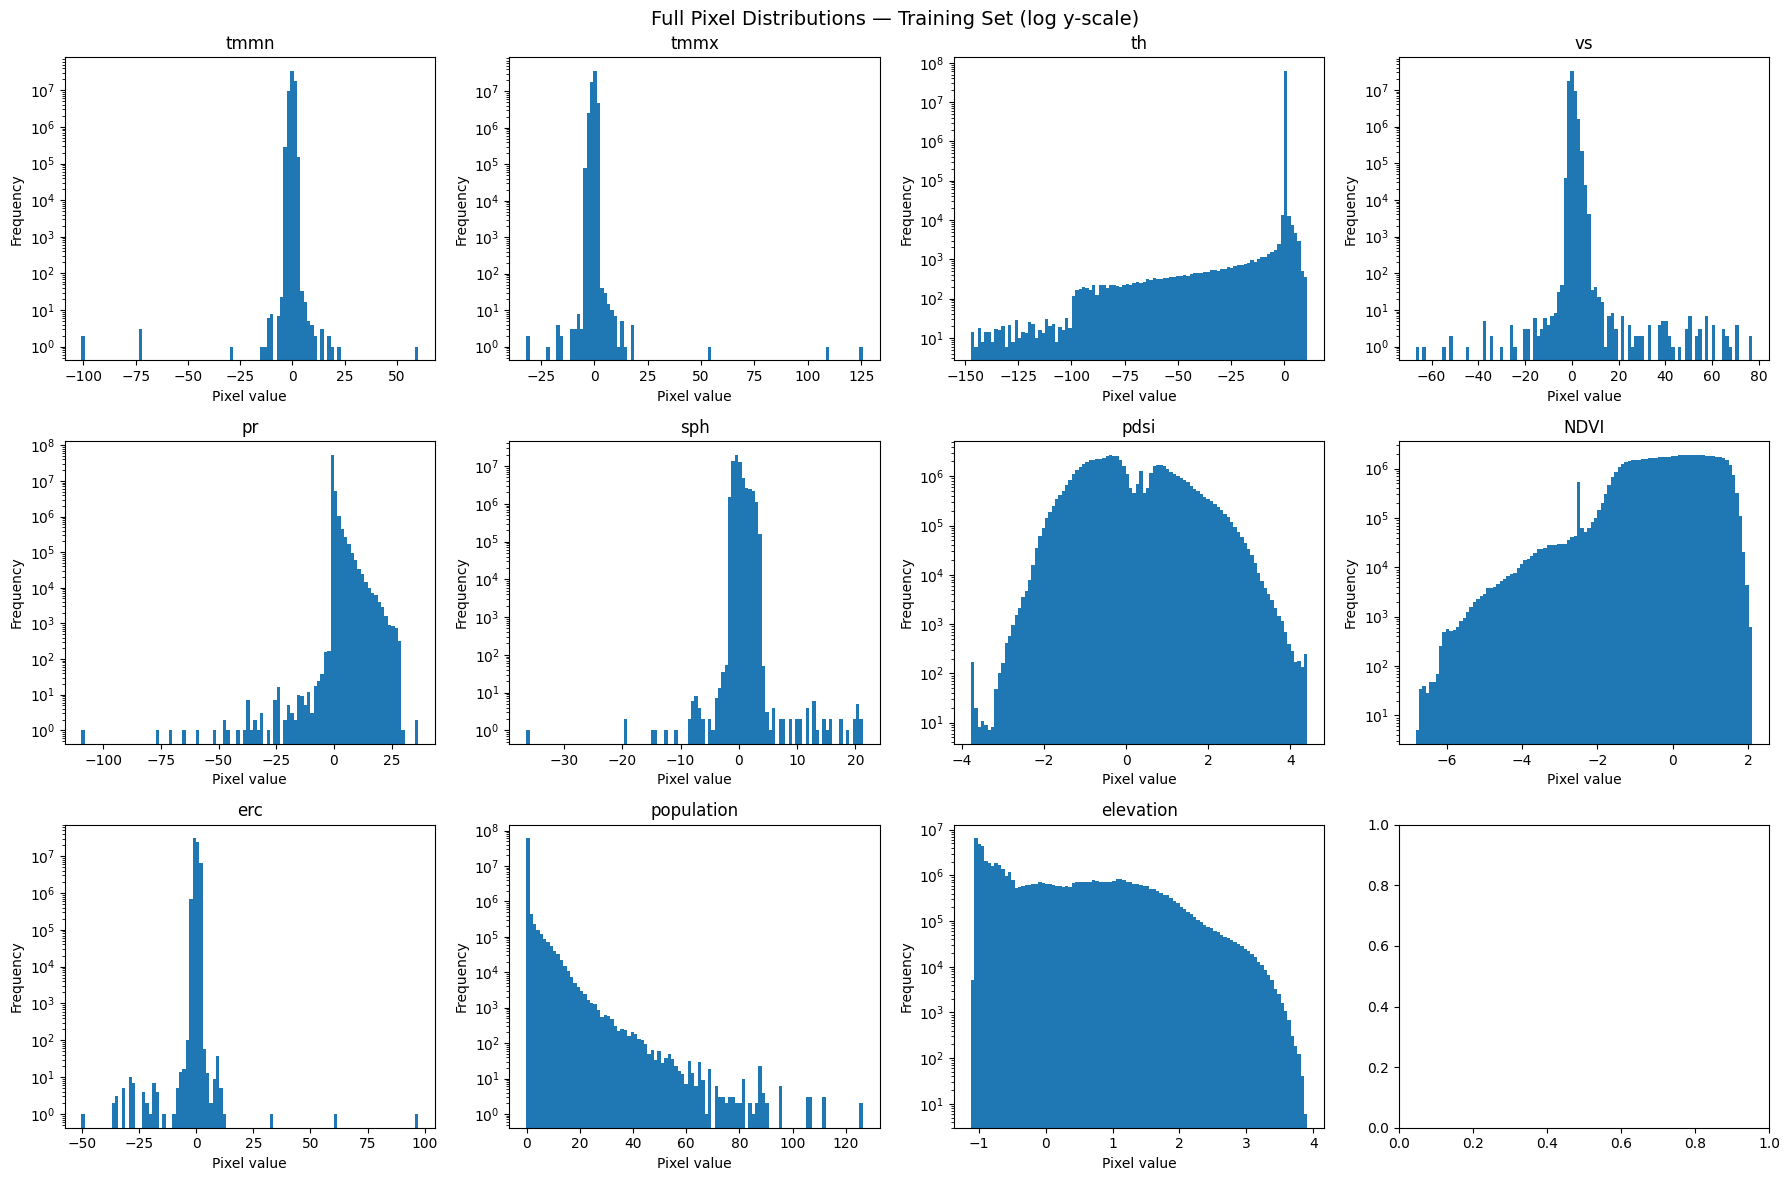

In [ ]:
# Features we'll quickly inspect
FEATURES = [f for f in INPUT_FEATURES if f != 'PrevFireMask']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    idx = INPUT_FEATURES.index(feat)
    data = X_train[..., idx].flatten()

    axes[i].hist(data, bins=100)
    axes[i].set_title(feat)
    axes[i].set_xlabel('Pixel value')
    axes[i].set_ylabel('Frequency')
    axes[i].set_yscale('log')  # log scale to see rare extreme values

plt.suptitle('Full Pixel Distributions — Training Set (log y-scale)', fontsize=14)
plt.tight_layout()
plt.show()

## Saving the training, validation, and test arrays

To work with the arrays made in this notebook, I'm saving them to a folder in Google Drive. This will ensure that the data is saved somewhere and that this preprocessing notebook doesn't have to be run each time access to the arrays are needed.

In [19]:
SAVE_PATH = '/content/drive/MyDrive/wildfire-prediction-data/processed-data/'
os.makedirs(SAVE_PATH, exist_ok=True)

arrays = {
    'X_train': X_train,
    'Y_train': Y_train,
    'X_val':   X_val,
    'Y_val':   Y_val,
    'X_test':  X_test,
    'Y_test':  Y_test,
}

for name, arr in arrays.items():
    np.save(SAVE_PATH + name + '.npy', arr)
    print(f'Saved {name}: shape={arr.shape}, dtype={arr.dtype}')

print('\nAll arrays saved to', SAVE_PATH)

Saved X_train: shape=(14979, 64, 64, 12), dtype=float32
Saved Y_train: shape=(14979, 64, 64), dtype=float32
Saved X_val: shape=(1877, 64, 64, 12), dtype=float32
Saved Y_val: shape=(1877, 64, 64), dtype=float32
Saved X_test: shape=(1689, 64, 64, 12), dtype=float32
Saved Y_test: shape=(1689, 64, 64), dtype=float32

All arrays saved to /content/drive/MyDrive/wildfire-prediction-data/processed-data/
